# YFinance Analysis: Friday Close vs Monday Open
This notebook compares Friday close to Monday open, analyzes recent patterns, and charts weekly opens, closes, and Monday highs.

In [5]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

ticker = 'SPY'  # change to your preferred ticker
data = yf.download(ticker, period='3mo', interval='1d')
data = data[['Open','High','Close']]
data.dropna(inplace=True)
data['Day'] = data.index.day_name()
data.tail()

[*********************100%***********************]  1 of 1 completed


Price,Open,High,Close,Day
Ticker,SPY,SPY,SPY,
Date,,,,
2026-03-23,658.070007,662.619995,655.380005,Monday
2026-03-24,651.320007,657.030029,653.179993,Tuesday
2026-03-25,658.669983,660.890015,656.820007,Wednesday
2026-03-26,652.059998,654.849976,645.090027,Thursday
2026-03-27,642.500000,642.659973,635.080017,Friday


## Extract Friday Close & Monday Open

In [6]:
# Identify Fridays and Mondays
fridays = data[data['Day'] == 'Friday']
mondays = data[data['Day'] == 'Monday']

# Align pairs
comparison = []
for monday_date, monday_row in mondays.iterrows():
    prev_friday = fridays[fridays.index < monday_date].tail(1)
    if not prev_friday.empty:
        friday_close = prev_friday['Close'].values[0]
        monday_open = monday_row['Open']
        comparison.append({
            'Friday Close': friday_close,
            'Monday Open': monday_open,
            'Gap': monday_open - friday_close,
            'Monday High': monday_row['High'],
            'Date': monday_date
        })

df_comp = pd.DataFrame(comparison)
df_comp.set_index('Date', inplace=True)
df_comp

,Friday Close,Monday Open,Gap,Monday High
Date,,,,
2026-01-05,[681.309326171875],Ticker SPY 684.670145 Name: 2026-01-05 00:0...,Ticker SPY 3.360819 Name: 2026-01-05 00:00:...,Ticker SPY 687.552288 Name: 2026-01-05 00:0...
2026-01-12,[692.1796264648438],Ticker SPY 688.798884 Name: 2026-01-12 00:0...,Ticker SPY -3.380743 Name: 2026-01-12 00:00:...,Ticker SPY 694.194183 Name: 2026-01-12 00:0...
2026-01-26,[687.352783203125],Ticker SPY 688.609372 Name: 2026-01-26 00:0...,Ticker SPY 1.256589 Name: 2026-01-26 00:00:...,Ticker SPY 692.239473 Name: 2026-01-26 00:0...
2026-02-02,[690.0853271484375],Ticker SPY 687.701913 Name: 2026-02-02 00:0...,Ticker SPY -2.383414 Name: 2026-02-02 00:00:...,Ticker SPY 695.031871 Name: 2026-02-02 00:0...
2026-02-09,[688.739013671875],Ticker SPY 687.542306 Name: 2026-02-09 00:0...,Ticker SPY -1.196708 Name: 2026-02-09 00:00:...,Ticker SPY 693.974751 Name: 2026-02-09 00:0...
2026-02-23,[687.5523071289062],Ticker SPY 685.95668 Name: 2026-02-23 00:00...,Ticker SPY -1.595627 Name: 2026-02-23 00:00:...,Ticker SPY 688.120753 Name: 2026-02-23 00:0...
2026-03-02,[684.1216430664062],Ticker SPY 676.851544 Name: 2026-03-02 00:0...,Ticker SPY -7.270099 Name: 2026-03-02 00:00:...,Ticker SPY 686.74451 Name: 2026-03-02 00:00...
2026-03-09,[670.5487060546875],Ticker SPY 664.57508 Name: 2026-03-09 00:00...,Ticker SPY -5.973626 Name: 2026-03-09 00:00:...,Ticker SPY 678.068199 Name: 2026-03-09 00:0...
2026-03-16,[660.4862060546875],Ticker SPY 666.559632 Name: 2026-03-16 00:0...,Ticker SPY 6.073426 Name: 2026-03-16 00:00:...,Ticker SPY 670.239584 Name: 2026-03-16 00:0...


c:\Users\hkhat\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
c:\Users\hkhat\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\cbook.py:1345: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


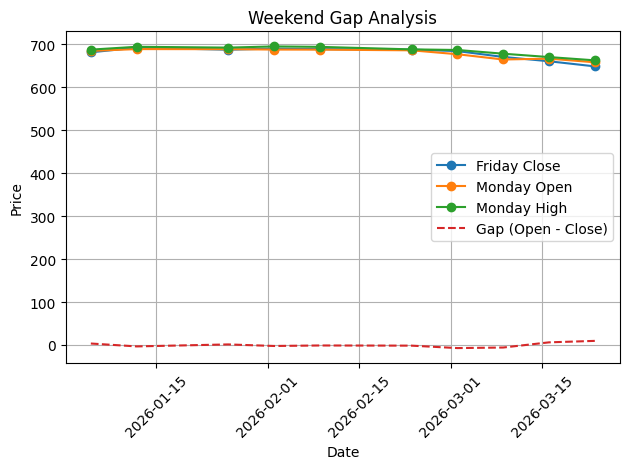

In [7]:

# Ensure index is sorted (important for plotting)
df_comp = df_comp.sort_index()

plt.figure()

# Plot lines
plt.plot(df_comp.index, df_comp['Friday Close'], marker='o', label='Friday Close')
plt.plot(df_comp.index, df_comp['Monday Open'], marker='o', label='Monday Open')
plt.plot(df_comp.index, df_comp['Monday High'], marker='o', label='Monday High')

# Optional: visualize the gap as a separate line
plt.plot(df_comp.index, df_comp['Gap'], linestyle='--', label='Gap (Open - Close)')

# Formatting
plt.xticks(rotation=45)
plt.title('Weekend Gap Analysis')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [11]:
fridays = data[data['Day'] == 'Friday']
mondays = data[data['Day'] == 'Monday']

comparison = []

for monday_date, monday_row in mondays.iterrows():
    prev_friday = fridays[fridays.index < monday_date].tail(1)
    if not prev_friday.empty:
        friday_close = float(prev_friday['Close'].iloc[0])
        monday_open = float(monday_row['Open'])
        monday_high = float(monday_row['High'])

        comparison.append({
            'Date': monday_date,
            'Friday Close': friday_close,
            'Monday Open': monday_open,
            'Gap': monday_open - friday_close,
            'Monday High': monday_high
        })

df_comp = pd.DataFrame(comparison).set_index('Date')
df_comp

C:\Users\hkhat\AppData\Local\Temp\ipykernel_17236\267825193.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  friday_close = float(prev_friday['Close'].iloc[0])
C:\Users\hkhat\AppData\Local\Temp\ipykernel_17236\267825193.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  monday_open = float(monday_row['Open'])
C:\Users\hkhat\AppData\Local\Temp\ipykernel_17236\267825193.py:11: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  monday_high = float(monday_row['High'])


,Friday Close,Monday Open,Gap,Monday High
Date,,,,
2026-01-05,681.309326,684.670145,3.360819,687.552288
2026-01-12,692.179626,688.798884,-3.380743,694.194183
2026-01-26,687.352783,688.609372,1.256589,692.239473
2026-02-02,690.085327,687.701913,-2.383414,695.031871
2026-02-09,688.739014,687.542306,-1.196708,693.974751
2026-02-23,687.552307,685.956680,-1.595627,688.120753
2026-03-02,684.121643,676.851544,-7.270099,686.744510
2026-03-09,670.548706,664.575080,-5.973626,678.068199
2026-03-16,660.486206,666.559632,6.073426,670.239584


In [12]:
import pandas as pd

# Make sure these columns are numeric
for col in ['Friday Close', 'Monday Open', 'Monday High', 'Gap']:
    df_comp[col] = pd.to_numeric(df_comp[col], errors='coerce')

# Monday move after open
df_comp['Move After Open'] = df_comp['Monday High'] - df_comp['Monday Open']

summary = pd.DataFrame({
    'Metric': [
        'Avg Gap',
        'Avg Up Gap',
        'Avg Down Gap',
        'Max Gap',
        'Min Gap',
        'Avg Move After Open',
        'Max Move After Open',
        'Min Move After Open'
    ],
    'Value': [
        df_comp['Gap'].mean(),
        df_comp.loc[df_comp['Gap'].gt(0), 'Gap'].mean(),
        df_comp.loc[df_comp['Gap'].lt(0), 'Gap'].mean(),
        df_comp['Gap'].max(),
        df_comp['Gap'].min(),
        df_comp['Move After Open'].mean(),
        df_comp['Move After Open'].max(),
        df_comp['Move After Open'].min()
    ]
})

summary

,Metric,Value
0,Avg Gap,-0.160938
1,Avg Up Gap,5.047708
2,Avg Down Gap,-3.633369
3,Max Gap,9.500000
4,Min Gap,-7.270099
5,Avg Move After Open,5.945004
6,Max Move After Open,13.493119
7,Min Move After Open,2.164073
